In [1]:
import os
import glob
from tqdm import tqdm
import numpy as np
import pandas as pd
import torch
import random
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import xarray as xr
import rasterio
import matplotlib.pyplot as plt
import albumentations as A
from albumentations.pytorch import ToTensorV2

In [2]:
def seed_everything(seed=28):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(28)

In [3]:
class AI4BoundariesDataset(Dataset):
    def __init__(
        self,
        image_paths,
        mask_paths,
        mode="single_month",
        month_index=4,
        normalize=True,
        transform=None
    ):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.mode = mode
        self.month_index = month_index
        self.normalize = normalize
        self.transform = transform

        self.mask_dict = {
            os.path.basename(p).replace(".tif", ""): p
            for p in mask_paths
        }

    def __len__(self):
        return len(self.image_paths)

    def _normalize(self, img):
        p2 = np.nanpercentile(img, 2, axis=(1, 2), keepdims=True)
        p98 = np.nanpercentile(img, 98, axis=(1, 2), keepdims=True)
        denominator = p98 - p2 + 1e-6
        img = (img - p2) / denominator
        img = np.nan_to_num(img, nan=0.0)
        return np.clip(img, 0, 1)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        basename = os.path.basename(img_path).replace(".nc", "")

        with xr.open_dataset(img_path) as ds:
            if self.mode == "single_month":
                t = self.month_index
                channels = []
                for band in ["B2", "B3", "B4", "B8", "NDVI"]:
                    arr = ds[band].isel(time=t).values
                    channels.append(arr)
                image = np.stack(channels, axis=0) # (C, H, W)

            elif self.mode == "temporal_stack":
                channels = []
                for band in ["B2", "B3", "B4", "B8", "NDVI"]:
                    arr = ds[band].values
                    channels.append(arr)
                image = np.concatenate(channels, axis=0)
            else:
                raise ValueError("Unknown mode")

        image = np.nan_to_num(image, nan=0.0, posinf=0.0, neginf=0.0)

        if self.normalize:
            image = self._normalize(image)

        mask_path = self.mask_dict[basename]
        with rasterio.open(mask_path) as src:
            mask = src.read(2)
        mask = np.nan_to_num(mask, nan=0.0)

        if self.transform:
            image_hwc = np.transpose(image, (1, 2, 0))
            
            augmented = self.transform(image=image_hwc, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
            
            if not isinstance(image, torch.Tensor):
                image = np.transpose(image, (2, 0, 1))
        
        if not isinstance(image, torch.Tensor):
            image = torch.tensor(image, dtype=torch.float32)
        if not isinstance(mask, torch.Tensor):
            mask = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)
        else:
            if mask.ndim == 2:
                mask = mask.unsqueeze(0)

        return image, mask

In [4]:
ROOT = "/kaggle/input/ai4boundaries-field-boundary-segmentation"

train_images = sorted(glob.glob(f"{ROOT}/train/train/*.nc"))
train_masks = sorted(glob.glob(f"{ROOT}/masks/train/*.tif"))

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.GaussianBlur(p=0.2),
    ToTensorV2(),
])

train_dataset = AI4BoundariesDataset(
    train_images,
    train_masks,
    mode="single_month",
    month_index=4,
    transform=train_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_images = sorted(glob.glob(f"{ROOT}/val/val/*.nc"))
val_masks = sorted(glob.glob(f"{ROOT}/masks/val/*.tif"))

val_dataset = AI4BoundariesDataset(
    val_images,
    val_masks,
    mode="single_month",
    month_index=4
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Train batches: 665
Validation batches: 143


In [5]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

In [6]:
class AttentionBlock(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super(AttentionBlock, self).__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)
        
    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi

In [7]:
class UNet(nn.Module):
    def __init__(self, in_channels=5, out_channels=1):
        super().__init__()

        # Encoder
        self.enc1 = DoubleConv(in_channels, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)

        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = DoubleConv(512, 1024)

        # Decoder
        self.up4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.att4 = AttentionBlock(F_g=512, F_l=512, F_int=256)
        self.dec4 = DoubleConv(1024, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.att3 = AttentionBlock(F_g=256, F_l=256, F_int=128)
        self.dec3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.att2 = AttentionBlock(F_g=128, F_l=128, F_int=64)
        self.dec2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.att1 = AttentionBlock(F_g=64, F_l=64, F_int=32)
        self.dec1 = DoubleConv(128, 64)

        self.final = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        # Bottleneck
        b = self.bottleneck(self.pool(e4))

        # Decoder
        d4 = self.up4(b)
        s4 = self.att4(g=d4, x=e4) 
        d4 = torch.cat([d4, s4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        s3 = self.att3(g=d3, x=e3)
        d3 = torch.cat([d3, s3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        s2 = self.att2(g=d2, x=e2)
        d2 = torch.cat([d2, s2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        s1 = self.att1(g=d1, x=e1)
        d1 = torch.cat([d1, s1], dim=1)
        d1 = self.dec1(d1)

        return self.final(d1)

In [8]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)

        probs = probs.view(-1)
        targets = targets.view(-1)

        intersection = (probs * targets).sum()
        dice = (2. * intersection + self.smooth) / (
            probs.sum() + targets.sum() + self.smooth
        )

        return 1 - dice

In [9]:
class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.5):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()
        self.bce_weight = bce_weight

    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets)
        dice_loss = self.dice(logits, targets)

        return self.bce_weight * bce_loss + (1 - self.bce_weight) * dice_loss

In [10]:
def compute_iou(logits, targets, threshold=0.5, eps=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    intersection = (preds * targets).sum(dim=(1,2,3))
    union = (preds + targets - preds * targets).sum(dim=(1,2,3))

    iou = (intersection + eps) / (union + eps)
    return iou.mean()

In [11]:
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler=None,
    epochs=20,
    device="cuda"
):
    scaler = torch.amp.GradScaler('cuda') 
    best_val_iou = 0.0
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        train_iou = 0
        
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
        for imgs, masks in pbar:
            imgs, masks = imgs.to(device), masks.to(device)
            
            optimizer.zero_grad()
            
            with torch.amp.autocast('cuda'):
                preds = model(imgs)
                loss = criterion(preds, masks)
            
            if torch.isnan(loss):
                print(f"\n[ERROR] Loss is NaN at Epoch {epoch+1}")
                return 

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            
            train_loss += loss.item()
            train_iou += compute_iou(preds, masks)
            
            pbar.set_postfix({"loss": loss.item()})

        train_loss /= len(train_loader)
        train_iou /= len(train_loader)

        model.eval()
        val_loss = 0
        val_iou = 0

        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device)

                with torch.amp.autocast('cuda'):
                    logits = model(images)
                    loss = criterion(logits, masks) 

                val_loss += loss.item()
                val_iou += compute_iou(logits, masks)

        val_loss /= len(val_loader)
        val_iou /= len(val_loader)
        
        if scheduler:
            scheduler.step(val_loss)

        if val_iou > best_val_iou:
            best_val_iou = val_iou
            torch.save(model.state_dict(), "best_model.pth")
            print(f"--> Saved best model with Val IoU: {val_iou:.4f}")

        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"Train Loss: {train_loss:.4f} | Train IoU: {train_iou:.4f}")
        print(f"Val   Loss: {val_loss:.4f} | Val   IoU: {val_iou:.4f}")
        print("-" * 50)

    print("Final Best Val IoU:", best_val_iou)

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet(in_channels=5, out_channels=1).to(device)
criterion = BCEDiceLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)


train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    epochs=20,
    device=device
)

Epoch 1/20: 100%|██████████| 665/665 [04:58<00:00,  2.23it/s, loss=0.569]


--> Saved best model with Val IoU: 0.2781

Epoch 1/20
Train Loss: 0.5983 | Train IoU: 0.2357
Val   Loss: 0.5467 | Val   IoU: 0.2781
--------------------------------------------------


Epoch 2/20: 100%|██████████| 665/665 [04:22<00:00,  2.53it/s, loss=0.551]



Epoch 2/20
Train Loss: 0.5439 | Train IoU: 0.2533
Val   Loss: 0.5163 | Val   IoU: 0.2724
--------------------------------------------------


Epoch 3/20: 100%|██████████| 665/665 [04:27<00:00,  2.49it/s, loss=0.492]


...


Epoch 18/20
Train Loss: 0.4325 | Train IoU: 0.3218
Val   Loss: 0.4352 | Val   IoU: 0.3386
--------------------------------------------------


Epoch 19/20: 100%|██████████| 665/665 [04:55<00:00,  2.25it/s, loss=0.396]



Epoch 19/20
Train Loss: 0.4299 | Train IoU: 0.3224
Val   Loss: 0.4414 | Val   IoU: 0.3204
--------------------------------------------------


Epoch 20/20: 100%|██████████| 665/665 [04:54<00:00,  2.26it/s, loss=0.441]


--> Saved best model with Val IoU: 0.3515

Epoch 20/20
Train Loss: 0.4276 | Train IoU: 0.3269
Val   Loss: 0.4345 | Val   IoU: 0.3515
--------------------------------------------------
Final Best Val IoU: tensor(0.3515, device='cuda:0')


In [13]:
torch.save(model.state_dict(), "unet_ai4boundaries.pth")

In [14]:
test_images = sorted(glob.glob(f"{ROOT}/test/test/*.nc"))
test_masks = sorted(glob.glob(f"{ROOT}/masks/test/*.tif"))

test_dataset = AI4BoundariesDataset(
    test_images,
    test_masks,
    mode="single_month",
    month_index=4
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [15]:
def dice_coef(pred, target, smooth=1e-6):
    pred = (pred > 0.5).float()
    intersection = (pred * target).sum(dim=(1,2,3))
    union = pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3))
    return ((2. * intersection + smooth) / (union + smooth)).mean().item()

def iou_score(pred, target, smooth=1e-6):
    pred = (pred > 0.5).float()
    intersection = (pred * target).sum(dim=(1,2,3))
    union = (pred + target).sum(dim=(1,2,3)) - intersection
    return ((intersection + smooth) / (union + smooth)).mean().item()

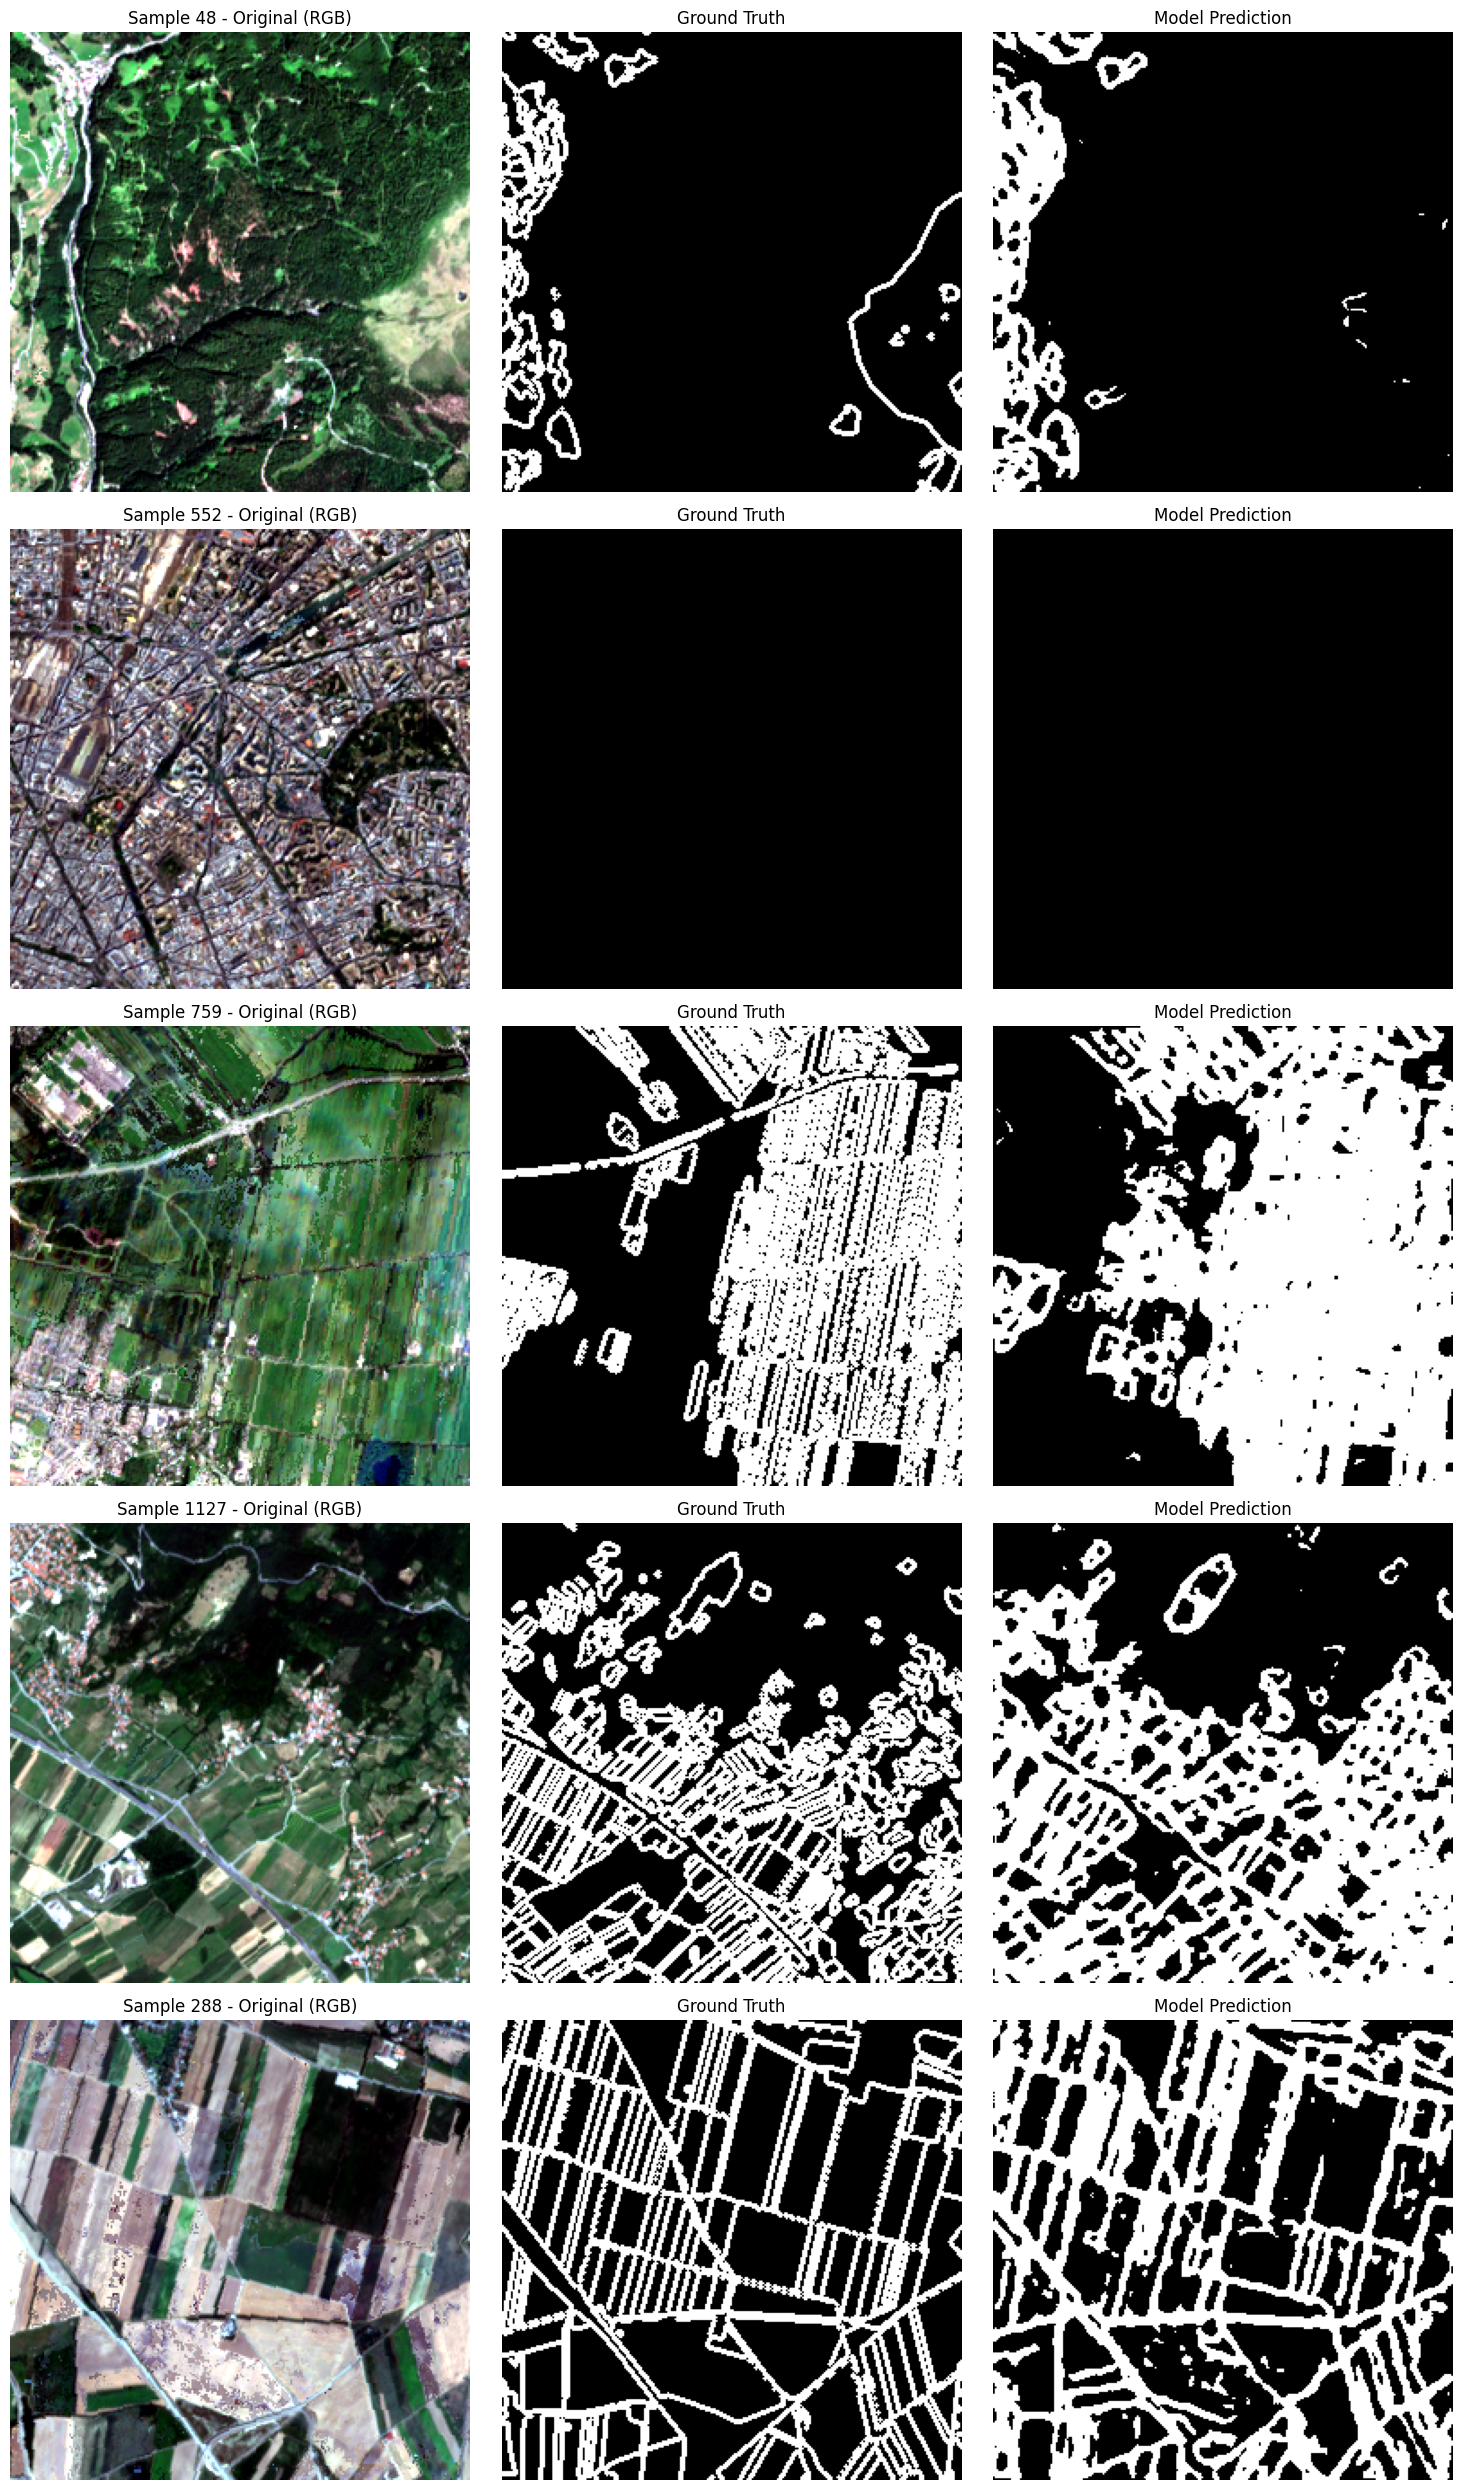

In [16]:
def visualize_predictions(model, dataset, num_samples=3, device="cuda"):
    model.eval()
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5 * num_samples))
    
    for i, idx in enumerate(indices):
        image, mask = dataset[idx]
        
        rgb_img = image[[2, 1, 0], :, :].permute(1, 2, 0).numpy()
        
        with torch.no_grad():
            input_tensor = image.unsqueeze(0).to(device)
            logits = model(input_tensor)
            probs = torch.sigmoid(logits).squeeze().cpu().numpy()
            pred_mask = (probs > 0.5).astype(np.float32)
            
        gt_mask = mask.squeeze().numpy()
        
        axes[i, 0].imshow(rgb_img)
        axes[i, 0].set_title(f"Sample {idx} - Original (RGB)")
        axes[i, 0].axis('off')

        axes[i, 1].imshow(gt_mask, cmap='gray')
        axes[i, 1].set_title("Ground Truth")
        axes[i, 1].axis('off')
        
        axes[i, 2].imshow(pred_mask, cmap='gray')
        axes[i, 2].set_title("Model Prediction")
        axes[i, 2].axis('off')
        
    plt.tight_layout()
    plt.show()

visualize_predictions(model, test_dataset, num_samples=5, device=device)

In [17]:
def evaluate(model, dataloader, device="cuda"):
    model.eval()
    dice_total, iou_total = 0, 0
    with torch.no_grad():
        for imgs, masks in dataloader:
            imgs, masks = imgs.to(device), masks.to(device)
            preds = model(imgs)
            dice_total += dice_coef(preds, masks)
            iou_total += iou_score(preds, masks)
    n_batches = len(dataloader)
    print(f"Dice: {dice_total / n_batches:.4f}, IoU: {iou_total / n_batches:.4f}")

evaluate(model, test_loader)

Dice: 0.4786, IoU: 0.3449
